In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from spisea import synthetic, evolution, atmospheres, reddening
from matplotlib.colors import LogNorm
import csv
from scipy.stats import chi2

/home/wyz5rge/.local/lib/python3.6/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /scratch/wyz5rge/models/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [2]:
# === Setup ===
iso_dir = 'isochrones/'
# output_dir = 'output_diagrams/'
# os.makedirs(output_dir, exist_ok=True)

# --- Static Parameters ---
star_index = 4
dist = 4500
metallicity = 0
log_age_arr = np.log10([1e6])  # 1 Myr

# Models
evo_model = evolution.Baraffe15()
atm_func = atmospheres.get_merged_atmosphere
red_law = reddening.RedLawCardelli(3.1)

# Filters
filt_list = ['jwst,F162M', 'jwst,F182M']
filters = ['m_jwst_F162M', 'm_jwst_F182M']

filter_wavelengths = {
    "m_jwst_F162M": 1.62,
    "m_jwst_F182M": 1.82,
    "m_jwst_F200W": 2.00,
    "m_jwst_F356M": 3.56,
    "m_jwst_F405N": 4.05
}

# Conversion constant from SPISEA/Cardelli (1989) with Rv = 3.1
AV_to_AKs = 1.0 / 0.1179  # ≈ 8.479

In [3]:
# --- Load star data ---
def load_star_data(csv_path, index=0):
    sample_mags, sample_errs = [], []
    with open(csv_path, mode='r') as file:
        reader = csv.reader(file)
        next(reader)
        for line in reader:
            mags = [float(line[i]) for i in range(1, len(line), 2)]
            errs = [float(line[i]) for i in range(2, len(line), 2)]
            sample_mags.append(mags)
            sample_errs.append(errs)
    return sample_mags[index][:2], sample_errs[index][:2]

# --- Interpolate Isochrone Points ---
def interpolate_isochrone(isochrone, num_interp=10):
    masses = isochrone.points['mass']
    m1 = isochrone.points['m_jwst_F162M']
    m2 = isochrone.points['m_jwst_F182M']

    # Collect original + interpolated points
    interp_data = []

    for i in range(len(masses) - 1):
        mass1, mass2 = masses[i], masses[i+1]
        m1_1, m1_2 = m1[i], m1[i+1]
        m2_1, m2_2 = m2[i], m2[i+1]

        # Interpolate mass values
        interp_masses = np.linspace(mass1, mass2, num=num_interp+2)[1:-1]
        interp_m1 = np.linspace(m1_1, m1_2, num=num_interp+2)[1:-1]
        interp_m2 = np.linspace(m2_1, m2_2, num=num_interp+2)[1:-1]

        for m, im1, im2 in zip(interp_masses, interp_m1, interp_m2):
            interp_data.append((m, im1, im2, False))  # False = interpolated

    # Add original points
    for i in range(len(masses)):
        interp_data.append((masses[i], m1[i], m2[i], True))  # True = original

    # Convert to structured array
    interp_data = sorted(interp_data, key=lambda x: x[0])
    dtype = [('mass', float), ('m_jwst_F162M', float), ('m_jwst_F182M', float), ('is_original', bool)]
    interp_array = np.array(interp_data, dtype=dtype)
    return interp_array

# --- Apply Dereddening ---
def apply_dereddening(mags, AKs, wavelengths):
    return [
        m - red_law.Cardelli89(wavelengths[filters[i]], AKs)
        for i, m in enumerate(mags)
    ]

# --- Compute Errors ---
def calculate_errors(errs):
    color_err = np.sqrt(errs[0]**2 + errs[1]**2)
    mag_err = errs[1]
    return color_err, mag_err

# --- Plotting Function ---
def plot_cmd_and_mmd(interp_table, dered_mags, errors, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    ax_cmd, ax_mmd = axes
    m162_d, m182_d = dered_mags
    color_err, mag_err = errors

    # Split by origin
    original = interp_table[interp_table['is_original']]
    interp = interp_table[~interp_table['is_original']]

    # === Color-Magnitude Diagram (CMD) ===
    colors_orig = original['m_jwst_F162M'] - original['m_jwst_F182M']
    mags_orig = original['m_jwst_F182M']
    colors_interp = interp['m_jwst_F162M'] - interp['m_jwst_F182M']
    mags_interp = interp['m_jwst_F182M']

    ax_cmd.plot(colors_orig, mags_orig, 'ro', markersize=3, label='Original')
    ax_cmd.plot(colors_interp, mags_interp, 'k.', markersize=2, alpha=0.5, label='Interpolated')
    ax_cmd.errorbar(m162_d - m182_d, m182_d, xerr=color_err, yerr=mag_err,
                    fmt='o', color='gold', alpha=0.9, label='Observed')

    ax_cmd.set_xlabel("F162M - F182M")
    ax_cmd.set_ylabel("F182M")
    ax_cmd.invert_yaxis()
    ax_cmd.set_title("Color-Magnitude Diagram")
    ax_cmd.grid(True)
    ax_cmd.legend()

    # === Magnitude-Magnitude Diagram (MMD) ===
    ax_mmd.plot(original['m_jwst_F162M'], original['m_jwst_F182M'], 'ro', markersize=3, label='Original')
    ax_mmd.plot(interp['m_jwst_F162M'], interp['m_jwst_F182M'], 'k.', markersize=2, alpha=0.5, label='Interpolated')
    ax_mmd.errorbar(m162_d, m182_d, xerr=errs[0], yerr=errs[1],
                    fmt='o', color='gold', alpha=0.9, label='Observed')

    ax_mmd.set_xlabel("F162M")
    ax_mmd.set_ylabel("F182M")
    ax_mmd.invert_yaxis()
    ax_mmd.invert_xaxis()
    ax_mmd.set_title("Magnitude–Magnitude Diagram")
    ax_mmd.grid(True)
    ax_mmd.legend()

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # --- Load star data from .dat file ---
def load_dat_star_data(dat_path, index=0):
    """
    Load photometry, errors, AV, and mass from a space-delimited .dat file.
    Skips the first two columns (assumed to be positional data).
    Returns:
        mags: list of observed magnitudes [F162M, F182M]
        errs: list of associated uncertainties
        av: extinction A(V)
        mass: estimated stellar mass
    """
    with open(dat_path, 'r') as f:
        lines = f.readlines()

    line = lines[index].strip().split()
    line = [float(x) for x in line]

    # Extract photometry and errors
    f162m, err_f162m = line[2], line[3]
    f182m, err_f182m = line[4], line[5]
    # f200m, err_f200m = line[6], line[7]  # Not used here, but available

    av = line[8]
    mass = line[9]

    mags = [f162m, f182m]
    errs = [err_f162m, err_f182m]
    return mags, errs, av, mass

Isochrone generation took 1.210047 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 0.00  dist = 4500
     Starting at:  2025-07-27 23:35:25.538533   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 21.99
Starting filter: jwst,F182M   Elapsed time: 0.66 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 22.18
      Time taken: 1.30 seconds
aks_result.x type: <class 'numpy.float64'> value: 1.4116410109273518
Best-fit AKs: 1.412, AV: 11.973


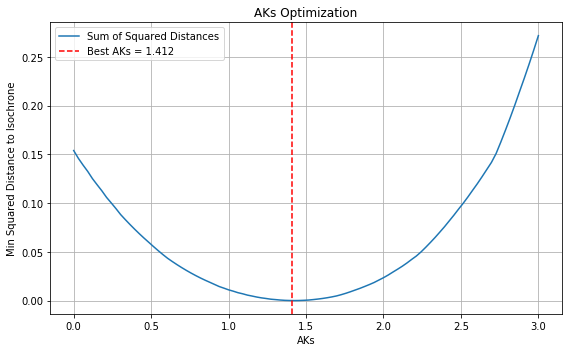

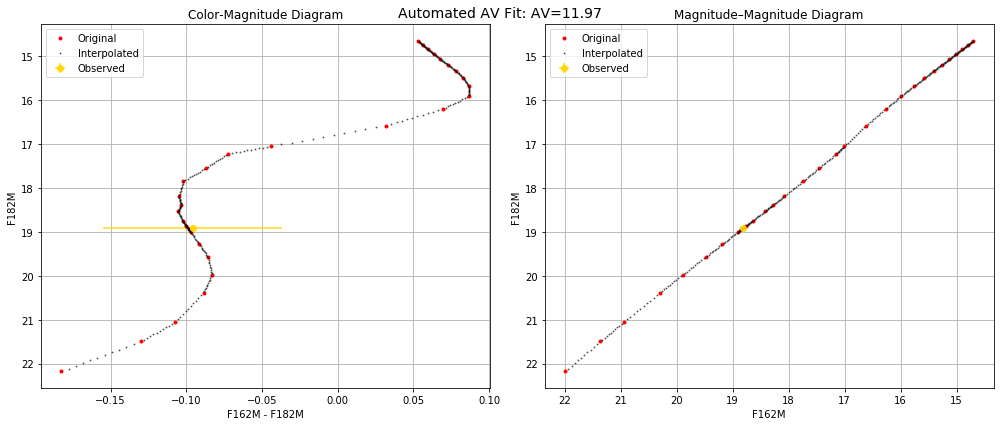

In [4]:
# === Read data ===
dat_path = '/scratch/wyz5rge/synthetic-hr/notebooks/2025/01-28_chi-square-reverse-modeling/winstonlist.dat'
mags, errs, av_true, mass_true = load_dat_star_data(dat_path, star_index)

# === Automate AKs selection ===
import scipy.optimize

# --- Compute sum of squared differences between dereddened point and isochrone ---
def compute_total_squared_distance(dered_mags, interp_table):
    # Color-magnitude of observed star
    color_obs = dered_mags[0] - dered_mags[1]  # F162M - F182M
    mag_obs = dered_mags[1]                   # F182M

    # Isochrone in CMD space using correct column names
    color_iso = interp_table['m_jwst_F162M'] - interp_table['m_jwst_F182M']
    mag_iso = interp_table['m_jwst_F182M']

    d_color = color_iso - color_obs
    d_mag = mag_iso - mag_obs
    distances_squared = d_color**2 + d_mag**2

    return np.min(distances_squared)

# --- Objective function to minimize ---
def objective(aks_trial, mags):
    aks_trial = float(np.squeeze(aks_trial))  # ensures scalar
    dered = apply_dereddening(mags, aks_trial, filter_wavelengths)
    # Return squared distance in color–magnitude space
    return compute_total_squared_distance(dered, interp_table)

# === Main execution (automated AKs) ===
from scipy.optimize import minimize_scalar

# Step 1: Generate unreddened isochrone and interpolate
iso_unredd = synthetic.IsochronePhot(log_age_arr[0], AKs=0.0, distance=dist,
                                     metallicity=metallicity,
                                     evo_model=evo_model, atm_func=atm_func,
                                     red_law=red_law, filters=filt_list,
                                     iso_dir=iso_dir)
interp_table = interpolate_isochrone(iso_unredd, num_interp=10)

# Step 2: Minimize AKs
aks_result = minimize_scalar(objective, bounds=(0.0, 3.0), args=(mags,), method='bounded')
print("aks_result.x type:", type(aks_result.x), "value:", aks_result.x)
AKs_val = float(np.squeeze(aks_result.x))
AV_val = AKs_val * AV_to_AKs
print(f"Best-fit AKs: {AKs_val:.3f}, AV: {AV_val:.3f}")

# Step 3: Plot sum of squares vs AKs (for visualization)
ak_grid = np.linspace(0.0, 3.0, 100)
sq_vals = [objective(ak, mags) for ak in ak_grid]
plt.figure(figsize=(8,5))
plt.plot(ak_grid, sq_vals, label='Sum of Squared Distances')
plt.axvline(AKs_val, color='r', linestyle='--', label=f'Best AKs = {AKs_val:.3f}')
plt.xlabel("AKs")
plt.ylabel("Min Squared Distance to Isochrone")
plt.title("AKs Optimization")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Step 4: Deredden mags and replot CMD/MMD with optimal AKs
dered_mags = apply_dereddening(mags, AKs_val, filter_wavelengths)
errors = calculate_errors(errs)
plot_cmd_and_mmd(interp_table, dered_mags, errors, f"Automated AV Fit: AV={AV_val:.2f}")

# Generate isochrone and interpolate
iso = synthetic.IsochronePhot(log_age_arr[0], AKs=0.0, distance=dist,
                               metallicity=metallicity,
                               evo_model=evo_model, atm_func=atm_func,
                               red_law=red_law, filters=filt_list,
                               iso_dir=iso_dir)

interp_table = interpolate_isochrone(iso, num_interp=10)

In [5]:
delta_AV = 5.0
AKs_margin = delta_AV / AV_to_AKs  # ≈ 0.59
AKs_low = max(0.0, AKs_val - AKs_margin)
AKs_high = AKs_val + AKs_margin
AKs_grid = np.arange(AKs_low, AKs_high + 0.001, 0.1 / AV_to_AKs)  # ≈ 0.012 steps

print(f"AKs grid: from {AKs_low:.3f} to {AKs_high:.3f} with {len(AKs_grid)} steps")

def chi_squared_grid(AKs_grid, mags, errs):
    results = []

    for aks in AKs_grid:
        iso = synthetic.IsochronePhot(log_age_arr[0], AKs=aks, distance=dist,
                                      metallicity=metallicity,
                                      evo_model=evo_model, atm_func=atm_func,
                                      red_law=red_law, filters=filt_list,
                                      iso_dir=iso_dir)
        interp = interpolate_isochrone(iso, num_interp=10)
        for entry in interp:
            model_mags = [entry[f] for f in filters]
            chi_sq = sum(
                ((mags[i] - model_mags[i]) ** 2) / max(errs[i] ** 2, 1e-3)
                for i in range(len(mags))
            ) / (len(mags) - 1)
            results.append({
                "AKs": aks,
                "AV": aks * AV_to_AKs,
                "mass": entry['mass'],
                "chi2": chi_sq
            })
    return results

grid_results = chi_squared_grid(AKs_grid, mags, errs)
grid_results_sorted = sorted(grid_results, key=lambda x: x["chi2"])

best_fit = grid_results_sorted[0]
print("\n=== Best Fit from Grid Search ===")
print(f"AV: {best_fit['AV']:.3f}")
print(f"AKs: {best_fit['AKs']:.3f}")
print(f"Mass: {best_fit['mass']:.4f} M☉")
print(f"Reduced χ²: {best_fit['chi2']:.4f}")

# Optional: top 5
print("\nTop 5 Fits:")
for r in grid_results_sorted[:5]:
    print(f"AV={r['AV']:.3f}, Mass={r['mass']:.4f}, χ²={r['chi2']:.4f}")

AKs grid: from 0.822 to 2.001 with 101 steps
Isochrone generation took 1.200702 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 0.82  dist = 4500
     Starting at:  2025-07-27 23:35:28.950155   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 23.30
Starting filter: jwst,F182M   Elapsed time: 0.66 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 23.26
      Time taken: 1.30 seconds
Isochrone generation took 1.197911 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 0.83  dist = 4500
     Starting at:  2025-07-27 23:35:31.471752   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 23.32
Starting filter: jwst,F182M   Elapsed time: 0.66 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 23.28
  

Starting filter: jwst,F182M   Elapsed time: 0.66 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 23.51
      Time taken: 1.31 seconds
Isochrone generation took 1.207116 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 1.02  dist = 4500
     Starting at:  2025-07-27 23:36:12.027960   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 23.62
Starting filter: jwst,F182M   Elapsed time: 0.65 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 23.53
      Time taken: 1.30 seconds
Isochrone generation took 1.205392 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 1.03  dist = 4500
     Starting at:  2025-07-27 23:36:14.552280   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 23.63
Starting filter:

Starting filter: jwst,F182M   Elapsed time: 0.66 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 23.77
      Time taken: 1.31 seconds
Isochrone generation took 1.201940 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 1.22  dist = 4500
     Starting at:  2025-07-27 23:36:54.995518   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 23.93
Starting filter: jwst,F182M   Elapsed time: 0.65 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 23.79
      Time taken: 1.31 seconds
Isochrone generation took 1.200027 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 1.23  dist = 4500
     Starting at:  2025-07-27 23:36:57.523950   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 23.95
Starting filter:

Starting filter: jwst,F182M   Elapsed time: 0.66 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 24.04
      Time taken: 1.31 seconds
Isochrone generation took 1.207638 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 1.42  dist = 4500
     Starting at:  2025-07-27 23:37:38.050642   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 24.25
Starting filter: jwst,F182M   Elapsed time: 0.65 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 24.05
      Time taken: 1.31 seconds
Isochrone generation took 1.200423 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 1.44  dist = 4500
     Starting at:  2025-07-27 23:37:40.580913   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 24.27
Starting filter:

Starting filter: jwst,F182M   Elapsed time: 0.66 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 24.30
      Time taken: 1.31 seconds
Isochrone generation took 1.200320 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 1.62  dist = 4500
     Starting at:  2025-07-27 23:38:21.124247   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 24.57
Starting filter: jwst,F182M   Elapsed time: 0.65 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 24.32
      Time taken: 1.31 seconds
Isochrone generation took 1.205155 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 1.64  dist = 4500
     Starting at:  2025-07-27 23:38:23.654524   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 24.59
Starting filter:

Starting filter: jwst,F182M   Elapsed time: 0.66 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 24.56
      Time taken: 1.31 seconds
Isochrone generation took 1.206252 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 1.82  dist = 4500
     Starting at:  2025-07-27 23:39:04.240738   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 24.88
Starting filter: jwst,F182M   Elapsed time: 0.66 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F182M = 24.58
      Time taken: 1.31 seconds
Isochrone generation took 1.207936 s.
Making photometry for isochrone: log(t) = 6.00  AKs = 1.84  dist = 4500
     Starting at:  2025-07-27 23:39:06.774460   Usually takes ~5 minutes
Starting filter: jwst,F162M   Elapsed time: 0.00 seconds
Starting synthetic photometry
M =   0.010 Msun  T =  2344 K  m_jwst_F162M = 24.90
Starting filter:

In [11]:
print(f"Estimated AV:    {best_fit['AV']:.3f}, Estimated Mass:  {best_fit['mass']:.4f} M☉")
print(f"Ground-truth AV: {av_true:.3f}, Ground-truth Mass: {mass_true:.4f} M☉")

Estimated AV:    12.073, Estimated Mass:  0.0728 M☉
Ground-truth AV: 10.538, Ground-truth Mass: 0.0562 M☉


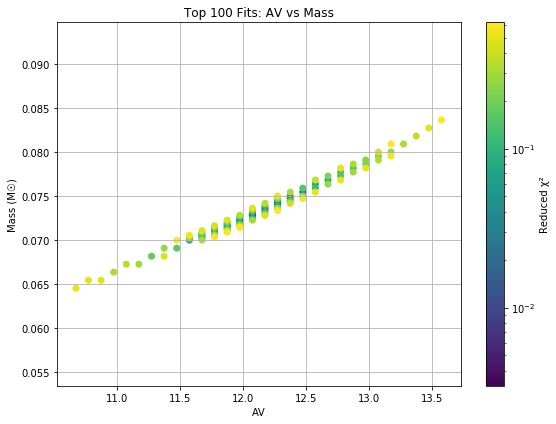

In [9]:
top = grid_results_sorted[:100]
avs = [r['AV'] for r in top]
masses = [r['mass'] for r in top]
chis = [r['chi2'] for r in top]

plt.figure(figsize=(8,6))
sc = plt.scatter(avs, masses, c=chis, cmap='viridis', norm=LogNorm())
plt.colorbar(sc, label="Reduced χ²")
plt.xlabel("AV")
plt.ylabel("Mass (M☉)")
plt.title("Top 100 Fits: AV vs Mass")
plt.grid(True)
plt.tight_layout()
plt.show()

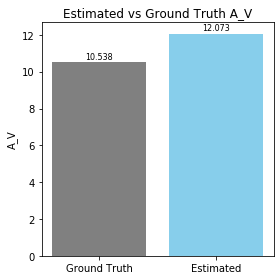

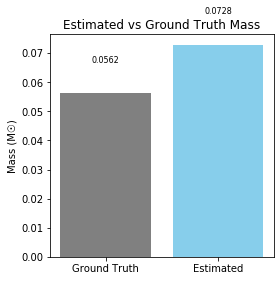

In [13]:
import matplotlib.pyplot as plt

# --- Plot A_V ---
plt.figure(figsize=(4, 4))
labels = ['Ground Truth', 'Estimated']
av_values = [av_true, best_fit['AV']]
x = range(len(labels))

plt.bar(x, av_values, color=['gray', 'skyblue'])
plt.xticks(x, labels)
plt.ylabel('A_V')
plt.title('Estimated vs Ground Truth A_V')

# Annotate bars
for i, val in enumerate(av_values):
    plt.text(i, val + 0.05, f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# --- Plot Mass ---
plt.figure(figsize=(4, 4))
mass_values = [mass_true, best_fit['mass']]

plt.bar(x, mass_values, color=['gray', 'skyblue'])
plt.xticks(x, labels)
plt.ylabel('Mass (M☉)')
plt.title('Estimated vs Ground Truth Mass')

# Annotate bars
for i, val in enumerate(mass_values):
    plt.text(i, val + 0.01, f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()